c:\Users\Dede\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


=== MEMULAI CUSTOM TRAINING LOOP (BACKPROPAGATION) ===
Epoch 010: Train Loss (MSE) = 0.005241 | Val Loss (MSE) = 0.009440
Epoch 020: Train Loss (MSE) = 0.004343 | Val Loss (MSE) = 0.005053
Epoch 030: Train Loss (MSE) = 0.004206 | Val Loss (MSE) = 0.005213
Epoch 040: Train Loss (MSE) = 0.004419 | Val Loss (MSE) = 0.004888
Epoch 050: Train Loss (MSE) = 0.004092 | Val Loss (MSE) = 0.004756
Epoch 060: Train Loss (MSE) = 0.004097 | Val Loss (MSE) = 0.005243
Epoch 070: Train Loss (MSE) = 0.003882 | Val Loss (MSE) = 0.005175
Epoch 080: Train Loss (MSE) = 0.003907 | Val Loss (MSE) = 0.011610
Epoch 090: Train Loss (MSE) = 0.003807 | Val Loss (MSE) = 0.004541


Epoch 100: Train Loss (MSE) = 0.003982 | Val Loss (MSE) = 0.004467

>>> Model Custom Backpropagation dan Scaler Berhasil Disimpan di 'model/'! <<<

     METRIK EVALUASI BACKPROPAGATION CUSTOM LOOP
Final Validation Loss (MSE): 0.004467
R-Squared (Akurasi Regresi): 98.51%
Convergence Rate (Durasi)  : 245.15 detik (untuk 100 Epoch)


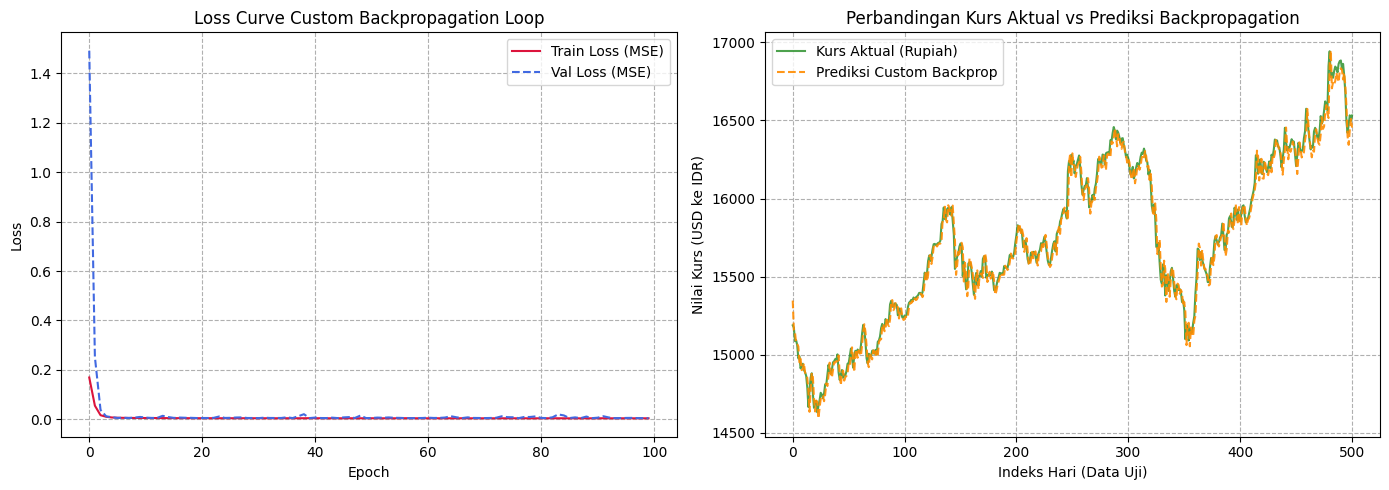

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib
import time # Untuk menghitung Convergence Rate (waktu komputasi)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# =====================================================================
# 1. LOAD DAN PREPROCESSING DATA (Sifat Time Series Windowing)
# =====================================================================
df = pd.read_csv('../data/USD-IDR.csv', sep=';')
df = df.dropna(subset=['Kurs'])
df = df.iloc[::-1].reset_index(drop=True) # Urutan kronologis (2015-2025)
df['Kurs'] = pd.to_numeric(df['Kurs'])

data_kurs = df['Kurs'].values.reshape(-1, 1)

# Menggunakan StandardScaler seperti pada contoh kodingan Backpropagation Anda
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_kurs)

# Membuat windowing dataset (menggunakan 5 hari sebelumnya untuk memprediksi hari ke-6)
def create_windowed_dataset(data, window_size=5):
    X, Y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        Y.append(data[i + window_size, 0])
    return np.array(X), np.array(Y)

WINDOW_SIZE = 5
X, Y = create_windowed_dataset(data_scaled, WINDOW_SIZE)
Y = Y.reshape(-1, 1) # Menjadikan target berdimensi 2D sesuai contoh Anda

# Split data kronologis (80% training, 20% testing)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
Y_train, Y_test = Y[:split_idx], Y[split_idx:]

# Convert numpy array menjadi TensorFlow Dataset untuk Custom Training Loop
batch_size = 32
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).shuffle(buffer_size=1024).batch(batch_size)

# =====================================================================
# 2. MEMBANGUN ARSITEKTUR MODEL BACKPROPAGATION
# =====================================================================
model = Sequential([
    Dense(16, activation='relu', input_shape=(WINDOW_SIZE,)),
    Dense(12, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='linear')
])

# Menggunakan Optimizer dan Loss Function murni
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn = tf.keras.losses.MeanSquaredError()

# List kosong untuk mencatat histori manual selama Custom Loop berjalan
train_loss_history = []
val_loss_history = []

# =====================================================================
# 3. KERAS CUSTOM TRAINING LOOP (MANUAL BACKPROPAGATION VIA GRADIENT TAPE)
# =====================================================================
epochs = 100
print("=== MEMULAI CUSTOM TRAINING LOOP (BACKPROPAGATION) ===")
start_time = time.time() # Penanda waktu awal untuk mengukur Convergence Rate

for epoch in range(epochs):
    epoch_loss_avg = tf.keras.metrics.Mean()
    
    # Proses Iterasi per Batch (Forward & Backward Pass)
    for x_batch_train, y_batch_train in train_dataset:
        with tf.GradientTape() as tape:
            # 1. Forward Pass (Maju melewati jaringan)
            y_pred = model(x_batch_train, training=True)
            loss_value = loss_fn(y_batch_train, y_pred)
            
        # 2. Backward Pass / Backpropagation (Hitung nilai Gradien Error terhadap Bobot Jaringan)
        grads = tape.gradient(loss_value, model.trainable_weights)
        
        # 3. Update Bobot (Mengubah bobot berdasarkan gradien error)
        optimizer.apply_gradients(zip(grads, model.trainable_weights))
        
        # Catat loss batch saat ini
        epoch_loss_avg.update_state(loss_value)
        
    # Hitung Loss data uji/validasi di akhir setiap epoch
    y_val_pred = model(X_test, training=False)
    val_loss = loss_fn(Y_test, y_val_pred)
    
    # Menyimpan nilai ke dalam histori
    train_loss_history.append(epoch_loss_avg.result().numpy())
    val_loss_history.append(val_loss.numpy())
    
    # Cetak perkembangan tiap 10 epoch agar konsol bersih
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d}: Train Loss (MSE) = {epoch_loss_avg.result().numpy():.6f} | Val Loss (MSE) = {val_loss.numpy():.6f}")

end_time = time.time() # Penanda waktu akhir training
duration = end_time - start_time

# =====================================================================
# 4. PROSES MENYIMPAN MODEL BACKPROPAGATION & SCALER
# =====================================================================
folder_model = '../model'
if not os.path.exists(folder_model):
    os.makedirs(folder_model)

# Model Backpropagation disimpan dalam format .h5, Scaler disimpan dalam format .pkl via joblib
model.save(os.path.join(folder_model, 'model_backprop_kurs.h5'))
joblib.dump(scaler, os.path.join(folder_model, 'scaler_backprop.pkl'))
print("\n>>> Model Custom Backpropagation dan Scaler Berhasil Disimpan di 'model/'! <<<")

# =====================================================================
# 5. EVALUASI AKHIR (LOSS, ACCURACY/R2, CONVERGENCE RATE)
# =====================================================================
# Melakukan prediksi data uji final
Y_pred_scaled = model(X_test, training=False).numpy()

# Denormalisasi kembali ke skala mata uang Rupiah asli
Y_test_actual = scaler.inverse_transform(Y_test)
Y_pred_actual = scaler.inverse_transform(Y_pred_scaled)

# Menghitung Metrik Evaluasi Akhir
final_val_loss = loss_fn(Y_test, Y_pred_scaled).numpy()
r2 = r2_score(Y_test_actual, Y_pred_actual) # Pengganti Metrik Accuracy khusus Kasus Regresi

print("\n" + "="*50)
print("     METRIK EVALUASI BACKPROPAGATION CUSTOM LOOP")
print("="*50)
print(f"Final Validation Loss (MSE): {final_val_loss:.6f}")
print(f"R-Squared (Akurasi Regresi): {r2 * 100:.2f}%")
print(f"Convergence Rate (Durasi)  : {duration:.2f} detik (untuk {epochs} Epoch)")
print("="*50)

# =====================================================================
# 6. VISUALISASI HASIL UNTUK BAHAN JURNAL
# =====================================================================
plt.figure(figsize=(14, 5))

# A. Plot Custom Loss Curve
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss (MSE)', color='crimson')
plt.plot(val_loss_history, label='Val Loss (MSE)', color='royalblue', linestyle='--')
plt.title('Loss Curve Custom Backpropagation Loop')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--')

# B. Plot Hasil Prediksi Aktual vs Hasil Custom Loop
plt.subplot(1, 2, 2)
plt.plot(Y_test_actual, label='Kurs Aktual (Rupiah)', color='forestgreen', alpha=0.8)
plt.plot(Y_pred_actual, label='Prediksi Custom Backprop', color='darkorange', linestyle='--', alpha=0.9)
plt.title('Perbandingan Kurs Aktual vs Prediksi Backpropagation')
plt.xlabel('Indeks Hari (Data Uji)')
plt.ylabel('Nilai Kurs (USD ke IDR)')
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()